In [3]:
import sys
sys.path.append(r"C:\Users\Sasmit\Desktop\Courses\3rd Year\Machine Design\RM_Python_Lib\rm_python_lib")



In [4]:
# import statements
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

import MechDesign.Helpers as HM

from MechDesign.Units.Units import m_, mm_, kg_, s_, N_, rpm_, W_, deg_
import MechDesign.Units.UnitMethods as UM

import MechDesign.RnM as RnM

In [5]:
# creating the chain to be calculated
CH = RnM.Chain()     #--- since Chain is part of the RnM library we call it as a part of it ---

In [6]:
final_shaft_speed_kmh = 15.5

final_shaft_speed_ms = final_shaft_speed_kmh * 1000 / 3600
print (final_shaft_speed_ms)

final_shaft_rpm = final_shaft_speed_ms / (2 * np.pi * (0.550/2)) * 60
print (final_shaft_rpm)

4.305555555555555
149.50918896511376


In [7]:
from sympy import symbols, Eq, solve

motor_shaft_rpm = 1500

i_total = motor_shaft_rpm / final_shaft_rpm
print (i_total)

i_1, i_2 = symbols( 'i_1 i_2', real=True, positive=True)
sol = solve( [Eq(i_1 * i_2, i_total), Eq(i_1/i_2, 0.6)], (i_1, i_2))

print (sol)

i_1 = sol[0][0]
i_2 = sol[0][1]
print (i_1)
print (i_2)

10.032828151786761
[(2.45350705951136, 4.08917843251893)]
2.45350705951136
4.08917843251893


In [8]:
middle_shaft_rpm = motor_shaft_rpm / i_1
print (middle_shaft_rpm)

611.369750979539


In [9]:
eta_belt = 0.96
eta_gear = 0.98
eta_bearing = 0.99
eta_coupling = 0.99

eta_total = eta_belt * eta_gear * (eta_bearing**4) * eta_coupling
print (eta_total)

0.89469143894592


In [10]:
P_output = 8000
 
P_input = P_output / eta_total 
print (P_input)

8941.630210997877


In [11]:
diameter_pulley_motor = 131.3 * mm_
diameter_pulley_middle = (diameter_pulley_motor * i_1) * mm_

print (diameter_pulley_motor)
print (diameter_pulley_middle)

131.3*mm_
322.145476913842*mm_**2


In [12]:
K_A = 2.2
required_motor_power = P_input * K_A

print (required_motor_power)

nominal_motor_power = 22000

selected_motor = "180-L"

print ("The selected motor is:", selected_motor)

19671.58646419533
The selected motor is: 180-L


In [13]:
# creating a new shaft connection, (this is 1 specific connection in your design)
SC = RnM.ShaftConnection() 

SC.p_gem = SC.E12_1B_KeyAveragePressure()  # this specific instance of SC.p_gem now hold the expression, with all of the symbols
HM.EqPrint('p_average',SC.p_gem) # as can be seen, the displayed formula is identical, except the left hand
dummy=HM.MyHelp(SC.p_gem)  # the explenations found are the default explenations

Eq(p_average, 2*_K_lambda*_T_eq/(_d*_hprime*_lprime*_n*_phi))

2*_K_lambda*_T_eq/(_d*_hprime*_lprime*_n*_phi)

    T_eq : [Nm] equivalent transmitted torque
    d : [mm] diameter of the shaft for splines: {tabel 12-3a} or addition for weakend section due to press fit screws (multiple ring press fit)
    n : [] number of keys or number of teeth of a spline
    hprime : [mm] h' is the effective height 
    K_lambda : [] load distribution factor method C: K_lambda = 1;  method B: {tabel 12-2c}
    lprime : [mm] effective length of the key
    phi : [] correction factor based on number of keys


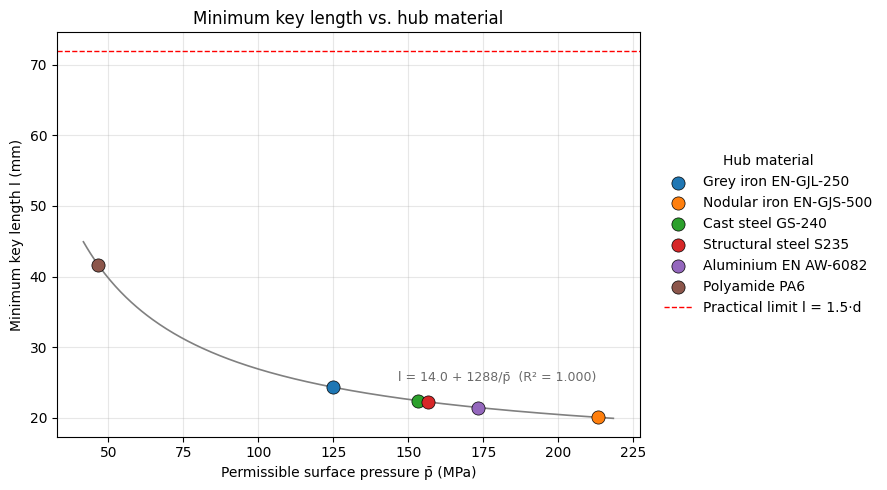

Grey iron EN-GJL-250       p̄ =  125.0 MPa   l_min =   24.3 mm
Nodular iron EN-GJS-500    p̄ =  213.3 MPa   l_min =   20.0 mm
Cast steel GS-240          p̄ =  153.3 MPa   l_min =   22.4 mm
Structural steel S235      p̄ =  156.7 MPa   l_min =   22.2 mm
Aluminium EN AW-6082       p̄ =  173.3 MPa   l_min =   21.4 mm
Polyamide PA6              p̄ =   46.7 MPa   l_min =   41.6 mm


In [27]:

# ---------- inputs (same values as your code) ----------
# P_input [W] and motor_shaft_rpm are defined earlier in your notebook
omega = motor_shaft_rpm * 2 * np.pi / 60       # rad/s
T_nom = P_input / omega                        # N·m
K_A = 2.2
T_eq = K_A * T_nom * 1000                      # N·mm (T_eq = K_A · T_nom)

d = 48.0                                       # mm
b, h = 14.0, 9.0                               # mm
h_prime = 0.45 * h                             # mm
n, phi, K_lambda = 1, 1, 1                     # 1 key, method C

# ---------- hub materials ----------
# R = Rm for brittle (S_B = 2), R = Re for ductile (S_F = 1.5), in MPa.
# R values are PLACEHOLDERS: replace them with your table 12-1 values.
materials = [
    ("Grey iron EN-GJL-250",    250, 2.0),   # brittle
    ("Nodular iron EN-GJS-500", 320, 1.5),
    ("Cast steel GS-240",       230, 1.5),
    ("Structural steel S235",   235, 1.5),
    ("Aluminium EN AW-6082",    260, 1.5),
    ("Polyamide PA6",            70, 1.5),
]

names, p_bars, key_lengths = [], [], []
for name, R, S in materials:
    p_bar = R / S                                              # MPa = N/mm²
    l_prime = 2 * K_lambda * T_eq / (d * h_prime * n * phi * p_bar)   # mm
    l_key = l_prime + b                                        # round-ended key: l = l' + b
    names.append(name); p_bars.append(p_bar); key_lengths.append(l_key)

# ---------- plot ----------
colors = plt.cm.tab10(np.arange(len(names)))
fig, ax = plt.subplots(figsize=(9, 5))

for name, x, y, c in zip(names, p_bars, key_lengths, colors):
    ax.scatter(x, y, s=90, color=c, label=name, zorder=3,
               edgecolor="k", linewidth=0.5)

# ---------- best fit: l = intercept + slope / p_bar ----------
p_arr = np.array(p_bars)
l_arr = np.array(key_lengths)

x_inv = 1 / p_arr
slope, intercept = np.polyfit(x_inv, l_arr, 1)      # straight line in 1/p_bar
l_fit = slope * x_inv + intercept
r2 = 1 - np.sum((l_arr - l_fit)**2) / np.sum((l_arr - l_arr.mean())**2)

x_curve = np.linspace(p_arr.min() - 5, p_arr.max() + 5, 300)
ax.plot(x_curve, slope / x_curve + intercept, color="gray", ls="-", lw=1.2)   # no label -> not in legend

# equation written directly next to the curve
x_txt = p_arr.min() + 0.60 * (p_arr.max() - p_arr.min())
y_txt = slope / x_txt + intercept
ax.text(x_txt, y_txt + 2, f"l = {intercept:.1f} + {slope:.0f}/p̄  (R² = {r2:.3f})",
        fontsize=9, color="dimgray", ha="left", va="bottom")

ax.axhline(1.5 * d, ls="--", color="red", lw=1, label="Practical limit l = 1.5·d")

ax.set_xlabel("Permissible surface pressure p̄ (MPa)")
ax.set_ylabel("Minimum key length l (mm)")
ax.set_title("Minimum key length vs. hub material")
ax.grid(alpha=0.3)
ax.legend(title="Hub material", loc="center left",
          bbox_to_anchor=(1.02, 0.5), frameon=False)
fig.tight_layout()
plt.show()

for nm, p, l_ in zip(names, p_bars, key_lengths):
    print(f"{nm:26s} p̄ = {p:6.1f} MPa   l_min = {l_:6.1f} mm")

In [40]:
# setting the value of known parameters
CH.n_1= middle_shaft_rpm * rpm_    
CH.n_2= final_shaft_rpm * rpm_
t=HM.EqPrint('n_1',CH.n_1)     

Eq(n_1, 611.4*rpm_)

In [41]:
# An initial estimate of the gear ratio is needed; the final gear ratio will depend on the number of teeth on both gear wheels.
iprime1 = CH.n_1/CH.n_2
t=HM.EqPrint('iprime1',iprime1)       

Eq(iprime1, 4.089)

In [43]:
CH.z_1 = 23
CH.z_2 = 94

CH.i = CH.E17_1B_GearRatioTeeth() 
t=HM.EqPrint('i',CH.i*mm_)

Eq(i, 4.087*mm_)